In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings
import os

# 1. 忽略警告並設定中文
warnings.filterwarnings('ignore')

def set_ch_font():
    system = platform.system()
    if system == "Windows": 
        plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
    elif system == "Darwin": 
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False

set_ch_font()
sns.set_theme(style="whitegrid", font=plt.rcParams['font.sans-serif'])

# 2. 讀取 01 產出的「清理後」表格
data_path = '../data/processed/cleaned_cycle3.csv'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    
    # 3. 建立視覺化用的標籤
    df['Group_Label'] = df['Smoking_Status'].map({0: '不吸菸組 (No)', 1: '吸菸組 (Yes)'})
    print(f"✅ 資料讀取成功！")
    print(f"原始無缺失總樣本共 {len(df)} 筆。\n")
    
    # 4. 🚀 針對 Research Question 的核心變數健康檢查
    if 'BMIPCT' in df.columns and 'Smoking_Status' in df.columns:
        # 計算同時擁有吸菸狀態與 BMI 數據的有效樣本
        valid_both = df[['Smoking_Status', 'BMIPCT']].notnull().all(axis=1).sum()
        print(f"📊 【Research Question 核心變數檢查】")
        print(f"  - 自變項 (Smoking_Status) 正常存在")
        print(f"  - 依變項 (BMIPCT) 正常存在，非空值共 {df['BMIPCT'].notnull().sum()} 筆")
        print(f"  - 💡 本單元兩者皆有效（可進入分析）的交叉樣本共 {valid_both} 筆")
    else:
        print("⚠️ 警告：找不到核心變數 'BMIPCT' 或 'Smoking_Status'，請檢查欄位名稱！")

else:
    print(f"❌ 找不到檔案：{data_path}")
    print("💡 請先確認是否已執行 01_data_check.ipynb 中的儲存步驟。")

✅ 資料讀取成功！
原始無缺失總樣本共 12437 筆。

📊 【Research Question 核心變數檢查】
  - 自變項 (Smoking_Status) 正常存在
  - 依變項 (BMIPCT) 正常存在，非空值共 12437 筆
  - 💡 本單元兩者皆有效（可進入分析）的交叉樣本共 12437 筆


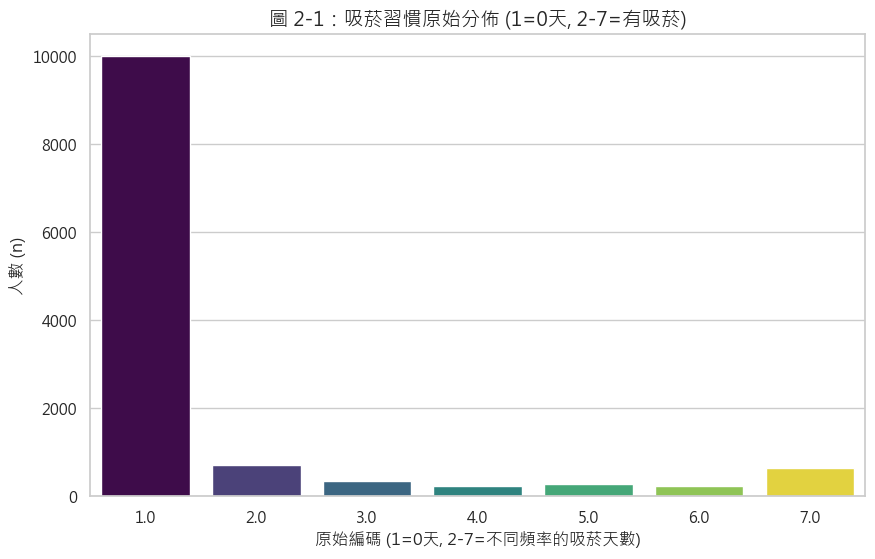

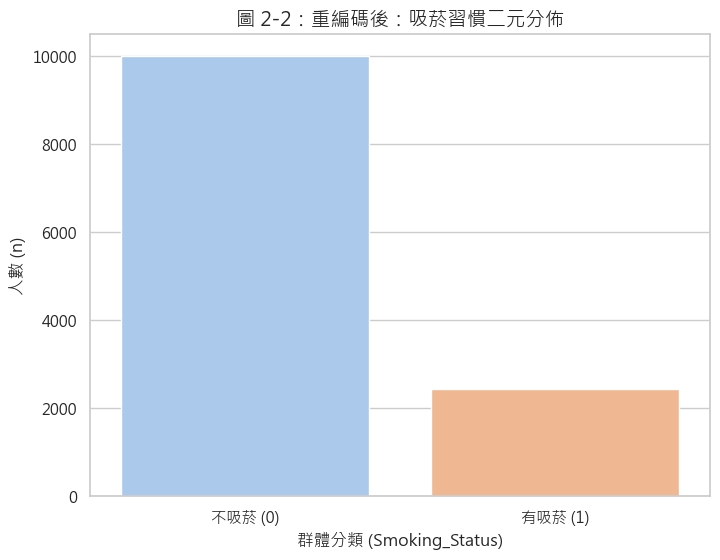

--------------------------------------------------
✅ 吸菸與 BMI 聯合清洗完成！
💡 最終可用於回答 Research Question 的有效兩組總樣本數：12437 筆
Smoking_Status
0    NaN
1    NaN
Name: count, dtype: object


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 🚀 關鍵修改：同時排除「吸菸習慣」與「BMI百分位數」的缺失值
# 這樣能確保此處算出的有效樣本，百分之百等於後續統計推論的樣本
df_smoke = df.dropna(subset=['CurrentCigaretteUse', 'BMIPCT']).copy()

# 2. 原始分佈圖 (圖 2-1)
# 目的：觀察 1-7 分類下，各個使用天數頻率的人數
fig_smoke_raw = plt.figure(figsize=(10, 6))
sns.countplot(x='CurrentCigaretteUse', data=df_smoke, palette='viridis', hue='CurrentCigaretteUse', legend=False)
plt.title('圖 2-1：吸菸習慣原始分佈 (1=0天, 2-7=有吸菸)', fontsize=14)
plt.xlabel('原始編碼 (1=0天, 2-7=不同頻率的吸菸天數)', fontsize=12)
plt.ylabel('人數 (n)', fontsize=12)
plt.show()

# 3. 執行二元重編碼 (Recoding)
# 定義：1 (0天) -> 0 (不吸菸) ; 2~7 (1天以上) -> 1 (有吸菸)
# 統一命名為 Smoking_Status 以符合後續分析
df_smoke['Smoking_Status'] = df_smoke['CurrentCigaretteUse'].apply(lambda x: 0 if x == 1 else 1)

# 4. 二元化分佈圖 (圖 2-2)
# 目的：確認簡化後的「對照組」與「實驗組」人數比例
fig_smoke_bin = plt.figure(figsize=(8, 6))
sns.countplot(x='Smoking_Status', data=df_smoke, palette='pastel', hue='Smoking_Status', legend=False)
plt.xticks([0, 1], ['不吸菸 (0)', '有吸菸 (1)'])
plt.title('圖 2-2：重編碼後：吸菸習慣二元分佈', fontsize=14)
plt.xlabel('群體分類 (Smoking_Status)', fontsize=12)
plt.ylabel('人數 (n)', fontsize=12)
plt.show()

print("-" * 50)
print(f"✅ 吸菸與 BMI 聯合清洗完成！")
print(f"💡 最終可用於回答 Research Question 的有效兩組總樣本數：{len(df_smoke)} 筆")
print(df_smoke['Smoking_Status'].value_counts().map({0: '不吸菸組 (0)', 1: '有吸菸組 (1)'}))

In [4]:
import pandas as pd

# --- 1. 吸菸變數：原始全表編碼頻率表 ---
print("【表 2-1：CurrentCigaretteUse 原始頻率表 (全表未篩選)】")
# 統計原始 1-7 代碼的人數分佈，包含 NaN (缺失值)
# 1=0天, 2=1-2天, 3=3-5天, 4=6-9天, 5=10-19天, 6=20-29天, 7=30天
original_freq = df['CurrentCigaretteUse'].value_counts(dropna=False).sort_index()
print(original_freq)

# --- 2. 原始全表之缺失與無效值計算 ---
missing_smoke = df['CurrentCigaretteUse'].isnull().sum()
# 檢查是否有 1-7 以外的範圍外異常值
invalid_smoke = len(df[~df['CurrentCigaretteUse'].isin(range(1, 8)) & df['CurrentCigaretteUse'].notnull()])

print(f"\n原始缺失值數量 (NaN): {missing_smoke}")
print(f"原始無效值數量 (非1-7): {invalid_smoke}")

# --- 3. 最終分析樣本（已聯立排除 BMI 缺失值）的頻率與比例 ---
smoke_stats = df_smoke['Smoking_Status'].value_counts().sort_index()
smoke_proportions = df_smoke['Smoking_Status'].value_counts(normalize=True).sort_index()

summary_table_smoke = pd.DataFrame({
    '最終分析人數 (Counts)': smoke_stats,
    '樣本佔比 (Proportions)': smoke_proportions.map(lambda x: f"{x:.2%}")
})

# 修改索引名稱讓表格
summary_table_smoke.index = ['不吸菸組 (No, 0)', '有吸菸組 (Yes, 1)']

print("\n" + "="*50)
print("【表 2-2：樣本之吸菸習慣二元化統計】")
print("註：此表已剔除 BMI (BMIPCT) 缺失值，為後續 t 檢定之基準群體")
print("="*50)
print(summary_table_smoke)

【表 2-1：CurrentCigaretteUse 原始頻率表 (全表未篩選)】
CurrentCigaretteUse
1.0    10003
2.0      720
3.0      353
4.0      235
5.0      270
6.0      221
7.0      635
Name: count, dtype: int64

原始缺失值數量 (NaN): 0
原始無效值數量 (非1-7): 0

【表 2-2：樣本之吸菸習慣二元化統計】
註：此表已剔除 BMI (BMIPCT) 缺失值，為後續 t 檢定之基準群體
               最終分析人數 (Counts) 樣本佔比 (Proportions)
不吸菸組 (No, 0)             10003             80.43%
有吸菸組 (Yes, 1)             2434             19.57%


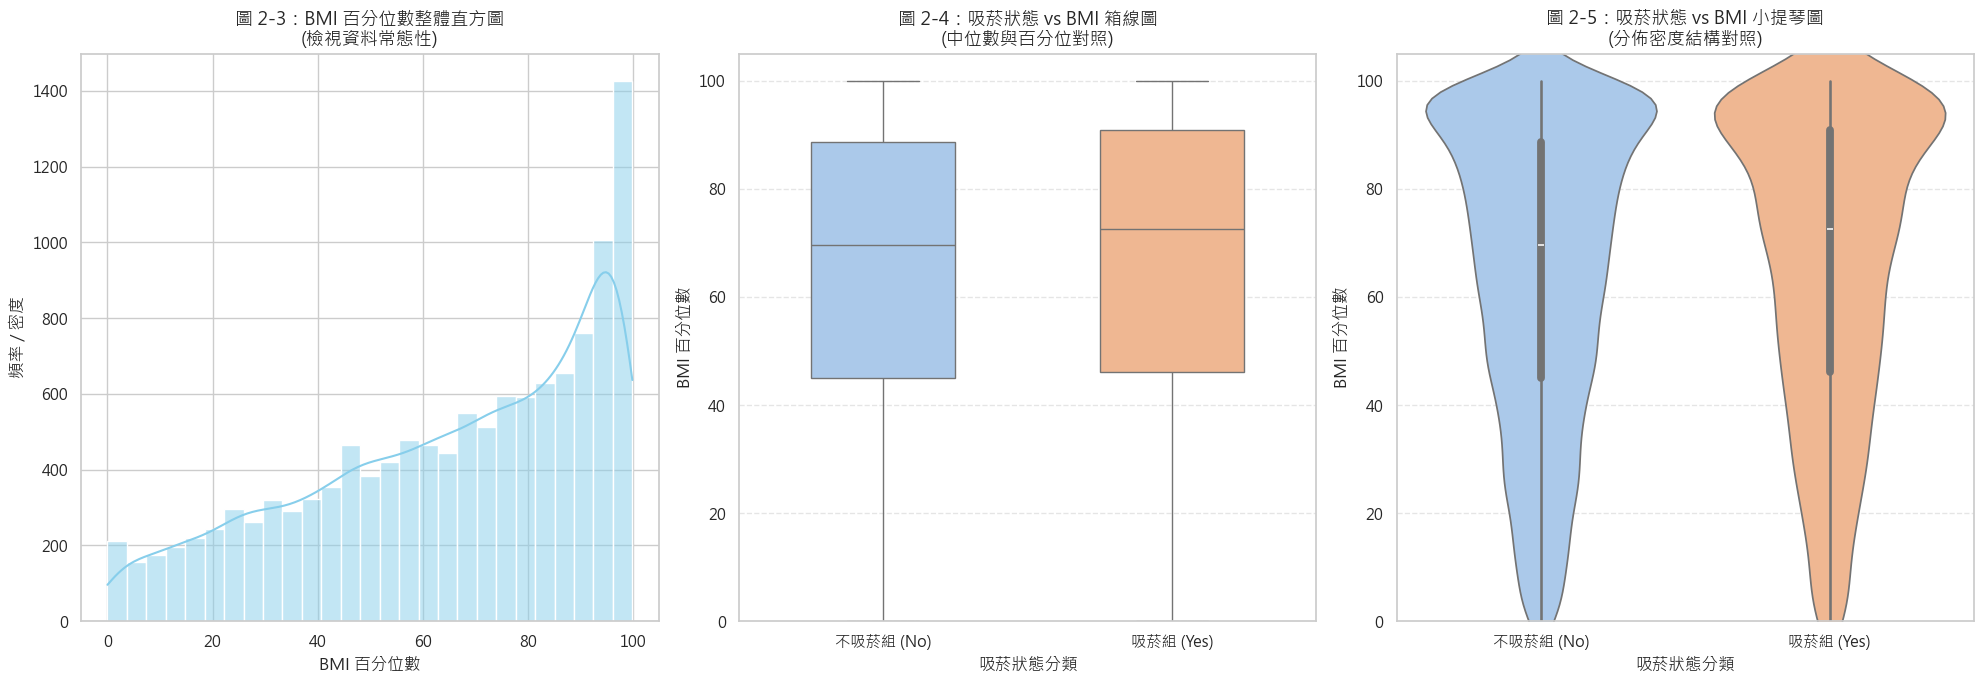

------------------------------------------------------------
✅ BMI 核心分佈與分組對照視覺化完成！
💡 本組圖表完全基於最終分析樣本，總人數：12437 筆


In [5]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 🚀 關鍵修改：不再手動建立 df_bmi，而是直接沿用上一步雙變數聯合清洗好的 df_smoke
# 這樣能保證有效樣本數與吸菸統計、後續 t 檢定完全一致！

# 2. 建立橫向排版大圖 (稍微加寬到 20 吋，給分組標籤留空間)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- (A) 整體直方圖 (Histogram) ---
# 目的：觀察整體 BMI 百分位數的偏態與常態性
sns.histplot(data=df_smoke, x='BMIPCT', kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('圖 2-3：BMI 百分位數整體直方圖\n(檢視資料常態性)', fontsize=13)
axes[0].set_xlabel('BMI 百分位數')
axes[0].set_ylabel('頻率 / 密度')

# --- (B) 分組箱線圖 (Boxplot) 🚀 升級分組對照 ---
# 目的：直擊研究問題，一眼看出兩組的中位數高低與離群值分佈
sns.boxplot(data=df_smoke, x='Group_Label', y='BMIPCT', palette='pastel', hue='Group_Label', legend=False, width=0.5, ax=axes[1])
axes[1].set_ylim(0, 105)
axes[1].set_title('圖 2-4：吸菸狀態 vs BMI 箱線圖\n(中位數與百分位對照)', fontsize=13)
axes[1].set_xlabel('吸菸狀態分類')
axes[1].set_ylabel('BMI 百分位數')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# --- (C) 分組小提琴圖 (Violin Plot) 🚀 升級分組對照 ---
# 目的：直擊研究問題，全面解構兩組人在不同體重區間的密集程度
sns.violinplot(data=df_smoke, x='Group_Label', y='BMIPCT', palette='pastel', hue='Group_Label', legend=False, ax=axes[2])
axes[2].set_ylim(0, 105)
axes[2].set_title('圖 2-5：吸菸狀態 vs BMI 小提琴圖\n(分佈密度結構對照)', fontsize=13)
axes[2].set_xlabel('吸菸狀態分類')
axes[2].set_ylabel('BMI 百分位數')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

# 優化間距並顯示
plt.tight_layout()
plt.show()

print("-" * 60)
print(f"✅ BMI 核心分佈與分組對照視覺化完成！")
print(f"💡 本組圖表完全基於最終分析樣本，總人數：{len(df_smoke)} 筆")

In [6]:
import pandas as pd
import numpy as np

# 1. 🚀 關鍵修改：沿用雙變數聯合清洗後的 df_smoke
# 拆分出全體、不吸菸組、吸菸組三個 Series
bmi_overall = df_smoke['BMIPCT']
bmi_nonsmoke = df_smoke[df_smoke['Smoking_Status'] == 0]['BMIPCT']
bmi_smoke = df_smoke[df_smoke['Smoking_Status'] == 1]['BMIPCT']

# 2. 建立分組敘述統計對照表
def get_stats_dict(series):
    return {
        '樣本數 (n)': len(series),
        '平均值 (Mean)': series.mean(),
        '中位數 (Median)': series.median(),
        '標準差 (SD)': series.std(),
        '最小值 (Min)': series.min(),
        '第一四分位數 (Q1)': series.quantile(0.25),
        '第三四分位數 (Q3)': series.quantile(0.75),
        '最大值 (Max)': series.max()
    }

# 整合至 DataFrame 中方便橫向對比
table_2_3 = pd.DataFrame({
    '全體樣本 (Overall)': get_stats_dict(bmi_overall),
    '不吸菸組 (Non-Smokers)': get_stats_dict(bmi_nonsmoke),
    '吸菸組 (Smokers)': get_stats_dict(bmi_smoke)
})

print("【表 2-3：BMI 百分位數數據統計摘要 (分組對照表)】")
# 統一四捨五入到小數點後兩位，並漂亮地印出表格
print(table_2_3.round(2))
print(f"註：原始全表中的 BMI 缺失值數量為: {df['BMIPCT'].isnull().sum()} 筆")

print("\n" + "="*60)
print("【離群值診斷 (Outlier Check by Group)】")

# 3. 🚀 升級：配合前方的分組箱線圖，分別檢查兩組的離群值
for label, series in [('不吸菸組', bmi_nonsmoke), ('吸菸組', bmi_smoke)]:
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    
    print(f"\n▶️ 【{label}】(n = {len(series)})")
    print(f"   離群值判定界線: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"   偵測到離群值數量: {len(outliers)} 筆 (佔該組比例: {len(outliers)/len(series):.2%})")

【表 2-3：BMI 百分位數數據統計摘要 (分組對照表)】
              全體樣本 (Overall)  不吸菸組 (Non-Smokers)  吸菸組 (Smokers)
樣本數 (n)             12437.00            10003.00        2434.00
平均值 (Mean)             64.75               64.39          66.23
中位數 (Median)           70.01               69.60          72.60
標準差 (SD)               27.50               27.47          27.57
最小值 (Min)               0.00                0.00           0.00
第一四分位數 (Q1)            45.15               44.91          46.08
第三四分位數 (Q3)            89.29               88.70          90.83
最大值 (Max)              99.94               99.93          99.94
註：原始全表中的 BMI 缺失值數量為: 0 筆

【離群值診斷 (Outlier Check by Group)】

▶️ 【不吸菸組】(n = 10003)
   離群值判定界線: [-20.77, 154.39]
   偵測到離群值數量: 0 筆 (佔該組比例: 0.00%)

▶️ 【吸菸組】(n = 2434)
   離群值判定界線: [-21.04, 157.95]
   偵測到離群值數量: 0 筆 (佔該組比例: 0.00%)


In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. 建立所有必要的目錄 (如果不存在則自動建立) ---
os.makedirs('../outputs/tables/', exist_ok=True)
os.makedirs('../outputs/figures/', exist_ok=True)
os.makedirs('../data/processed/', exist_ok=True)

# --- 2. 儲存統計表格 (Tables) ---
# 儲存吸菸二元化頻率表
summary_table_smoke.to_csv('../outputs/tables/02_smoking_summary.csv', encoding='utf-8-sig')

# 🚀 關鍵修改：儲存新版的分組描述性統計對照表 (table_2_3)
table_2_3.to_csv('../outputs/tables/02_bmi_group_summary.csv', encoding='utf-8-sig')
print("📊 統計表格已成功存入：../outputs/tables/")

# --- 3. 儲存視覺化圖表 (Figures) ---
save_fig_path = '../outputs/figures/'

# 儲存吸菸人數相關分佈圖 (圖 2-1 與 圖 2-2)
fig_smoke_raw.savefig(save_fig_path + '02_smoking_raw_dist.png', dpi=300, bbox_inches='tight')
fig_smoke_bin.savefig(save_fig_path + '02_smoking_binary_dist.png', dpi=300, bbox_inches='tight')

# 🚀 關鍵修改：將 3-in-1 的 BMI 核心分佈與分組對照圖組，整合成一張高解析度大圖儲存
# 這裡的 fig 變數對應了你上一格執行的 plt.subplots(1, 3) 物件
fig.savefig(save_fig_path + '02_bmi_combined_diagnostic_plots.png', dpi=300, bbox_inches='tight')

print(f"🖼️  EDA 視覺化圖表已全部存入：{save_fig_path}")

# --- 4. 儲存最終用於統計推論的資料檔 (Final Clean Data) ---
# 這裡儲存的是已經雙變數聯合清洗、完成重編碼的 df_smoke
# 這將作為 03_inference.ipynb 的輸入來源，確保兩階段有效樣本數 (n) 完美一致！
df_smoke.to_csv('../data/processed/yrbs_final_cycle3.csv', index=False, encoding='utf-8-sig')

print("-" * 50)
print("資料位置：../data/processed/yrbs_final_cycle3.csv")

📊 統計表格已成功存入：../outputs/tables/
🖼️  EDA 視覺化圖表已全部存入：../outputs/figures/
--------------------------------------------------
資料位置：../data/processed/yrbs_final_cycle3.csv
